In [ ]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "kwill580"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()
if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

#today_dir = "Assignments/HW3"
#os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/kwill580/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/kwill580/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design


# STAT 7220 - Homework 3
## Factorial Designs
## Dr. Austin Brown
## Due Date: April 10, 2026

## Part 1 Instructions:

A running shoe manufacturer wants to optimize the comfort of a new shoe model. They've identified three factors they believe will affect comfort:

| Factor | Level 1 (-) Description | Level 2 (+) Description |
|------------------------|------------------------|-------------------------|
| Sole Material (A) | Standard EVA foam | Advanced gel-infused foam |
| Insole Thickness (B) | 3mm | 6mm |
| Fabric Breathability (C) | Standard woven fabric | High-performance mesh fabric |

To evaluate the comfort of the $2^3=8$ runs, the manufacturer will recruit 3 NCAA division one cross-country athletes to test a randomly assigned shoe. Each athlete will run on a treadmill for 30 minutes in the shoes and rate the comfort on a scale of 1-10 (1 = very uncomfortable, 10 = very comfortable). The results of this experiment are contained in the `Shoe Comfort Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.
 * The objective of the experiment is to quantify the effect the main effects ( shoe sole material, insole thickness, and fabric breathability) as well as their interaction have on our outcome, overall comfort.

2.  Specify the outcome variable and how it is measured.

 * Outcome variable: Comfort (continuous), a numerical measurement made each athlete testing out the shoe.

3.  Specify the independent variables. What lurking variables may be present?
 * Independent variables: Sole Material, Insole Thickness, and Fabric breathability(nominal categorical variables)
 * Lurking variables: Athlete's personal  structural reinforcement requirements could alter their comfort ratings, skewing results. From athlete to athlete, comfort could be defined differently.


4.  Explain the difference between a full factorial design and a $2^k$ factorial design. Briefly comment on why the latter may be preferred in this case.
 * A full factorial design can have multiple factors with mulitple levels to each factor. With $2^k$ factorial designs, it is only two level to each factor. For example, in this shoe design experiment, it is either woven or mesh, 3mm or 6mm, these factors only have two levels.

5.  State the sets of null and alternative hypotheses for this experiment.

- For main effects:

$$ H_{01}: \alpha_{\text{EVA}} = \alpha_{\text{Gel}} = 0 $$
$$ H_{11}: \text{At least one } \alpha_i \neq 0 $$

$$ H_{02}: \beta_{\text{3mm}} = \beta_{\text{6mm}} = 0 $$
$$ H_{12}: \text{At least one } \beta_j \neq 0 $$

$$ H_{03}: \gamma_{\text{Woven}} = \gamma_{\text{Mesh}} = 0 $$
$$ H_{13}: \text{At least one } \gamma_k \neq 0 $$

- For two-way interactions:

$$ H_{04}: (\alpha\beta)_{ij} = 0 \text{ for all } i,j $$
$$ H_{14}: \text{At least one } (\alpha\beta)_{ij} \neq 0 $$

$$ H_{05}: (\alpha\gamma)_{ik} = 0 \text{ for all } i,k $$
$$ H_{15}: \text{At least one } (\alpha\gamma)_{ik} \neq 0 $$

$$ H_{06}: (\beta\gamma)_{jk} = 0 \text{ for all } j,k $$
$$ H_{16}: \text{At least one } (\beta\gamma)_{jk} \neq 0 $$

- For three-way interaction:

$$ H_{07}: (\alpha\beta\gamma)_{ijk} = 0 \text{ for all } i,j,k $$
$$ H_{17}: \text{At least one } (\alpha\beta\gamma)_{ijk} \neq 0 $$

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [ ]:
## Import Relevant Packages ##
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Read in Shoe Comfort Data ##

shoe_data = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW3/Shoe Comfort Experiment.xlsx")

## Data Integrity Check ##

print(shoe_data.info())

## Exploratory Data Analysis ##
## Start with Main Effects ##

## Shoe Material ##

material_stats = shoe_data.groupby("sole_material")["comfort"].agg(['mean', 'std'])

print(material_stats)

## Thickness ##

thickness_stats = shoe_data.groupby("insole_thickness")["comfort"].agg(['mean', 'std'])

print(thickness_stats)

## Breathability ##

breathing_stats = shoe_data.groupby("breathability")["comfort"].agg(['mean', 'std'])

print(breathing_stats)


## Material x Insole x Breathability ##

mat_insole_breath_stats = shoe_data.groupby(["sole_material", "insole_thickness", "breathability"])["comfort"].agg(['mean', 'std'])

print(mat_insole_breath_stats)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sole_material     24 non-null     object 
 1   insole_thickness  24 non-null     object 
 2   breathability     24 non-null     object 
 3   comfort           24 non-null     float64
dtypes: float64(1), object(3)
memory usage: 900.0+ bytes
None
               mean       std
sole_material                
EVA            7.10  1.068559
Gel            9.05  1.541841
                  mean       std
insole_thickness                
3mm               7.45  1.375434
6mm               8.70  1.687925
                   mean       std
breathability                    
Mesh           7.508333  1.273120
Woven          8.641667  1.808796
                                                   mean       std
sole_material insole_thickness breathability                     
EVA           3mm              Mes

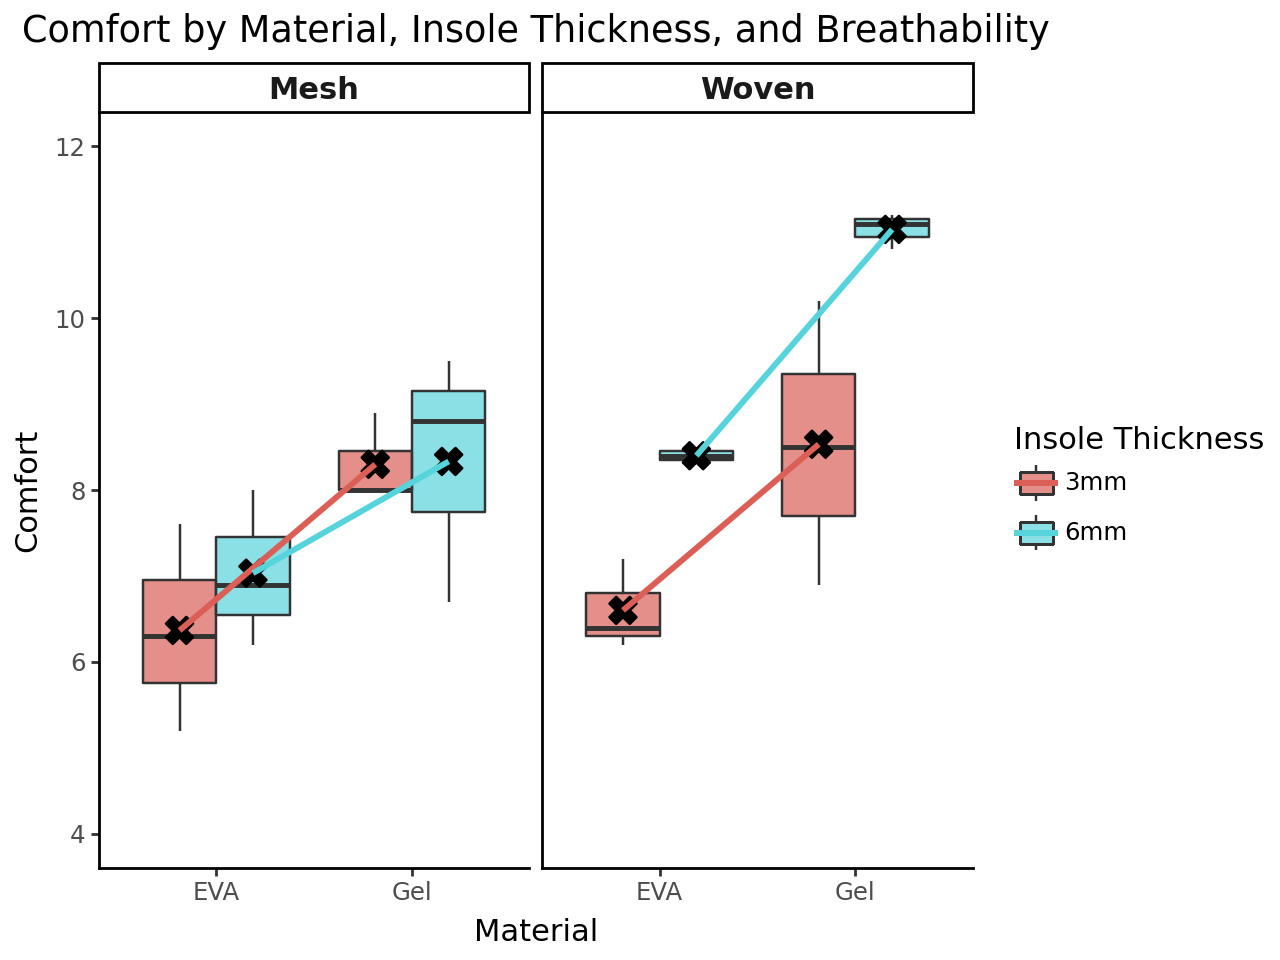

In [ ]:
## Install plotnine
#%pip install plotnine
## Import all plotnine functions ##:
from plotnine import *

# Prepare summarized data
shoe_means = mat_insole_breath_stats.reset_index()[["sole_material", "insole_thickness", "breathability", "mean"]]

# Define dodge position for aligning points/lines with the boxplots
box_dodge = position_dodge(0.75)

# Build a single faceted plot
p = (
    ggplot(shoe_data, aes(x='sole_material', y='comfort')) +

    # 1. Boxplot layer (base visualization)
    geom_boxplot(aes(fill='insole_thickness'), alpha=0.7, position=box_dodge) +

    # 2. Mean points (using separate summary data)
    geom_point(
        data=shoe_means,
        mapping=aes(y='mean', group='insole_thickness'),
        shape='X',
        size=5,
        position=box_dodge,
        color='black'
    ) +

    # 3. Mean lines
    geom_line(
        data=shoe_means,
        mapping=aes(y='mean', group='insole_thickness', color='insole_thickness'),
        size=1.2,
        position=box_dodge
    ) +

    # 4. Facet by Breathability (two panels side-by-side)
    facet_wrap('~breathability', ncol=2) +

    # 5. Styling and labels
    labs(
        title = "Comfort by Material, Insole Thickness, and Breathability",
        x = "Material",
        y = "Comfort",
        fill = "Insole Thickness",
        color = "Insole Thickness"
    ) +

    theme_classic() +
    theme(
        plot_title = element_text(hjust=0.5),
        strip_text = element_text(size=11, weight='bold')
    ) +

    scale_y_continuous(limits=(4, 12))
)

# Display
p

* The results of the summary statistics and visualizations supports the alternative hypothesis. The boxplot displaying a jump between 3mm and 6mm comparing both fabric types support the alternative hypothesis.

7.  Fit a full factorial ANOVA model to the data. Assess the normality assumption using both a visual method and a testing method. Do we have evidence to support the assumption of normality? Why or why not?


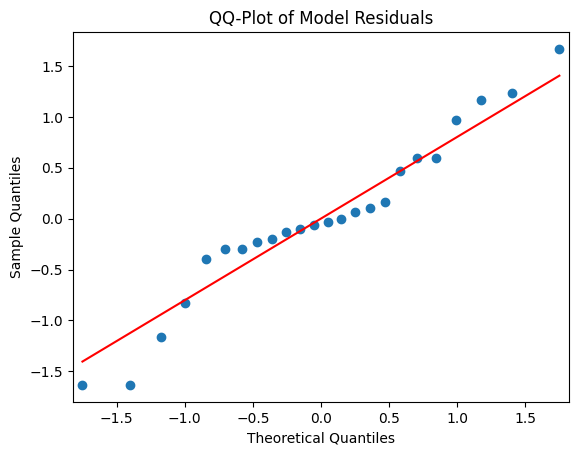

Shapiro-Wilk Test Results:
Statistic: 0.9575037531835807
p-value: 0.39035284823506383
Fail to reject the null hypothesis - Residuals are normally distributed.


In [ ]:
## Import Statsmodels ##
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

## Fit Full Factorial Model ##

model = ols('comfort ~ sole_material*insole_thickness*breathability', data=shoe_data).fit()

## Parse out model residuals ##

residuals = model.resid

## Test of Normality ##

## QQ-Plot ##

sm.qqplot(residuals, line='s')
plt.title("QQ-Plot of Model Residuals")
plt.show()

## Shapiro-Wilk Test ##

shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test Results:")
print(f"Statistic: {shapiro_test.statistic}")
print(f"p-value: {shapiro_test.pvalue}")
if shapiro_test.pvalue < 0.05:
    print("Reject the null hypothesis - Residuals are not normally distributed.")
else:
    print("Fail to reject the null hypothesis - Residuals are normally distributed.")





* There is slight deviation of points in the lower tail of the QQ plot. Since the p-value associated with the S-W test is greater than 0.05, we have no evidence to suggest that the normality assumption has been violated.

8.  Assess the constant variance assumption using both a visual method and a testing method. Do we have evidence to support the assumption of constant variance? Why or why not?


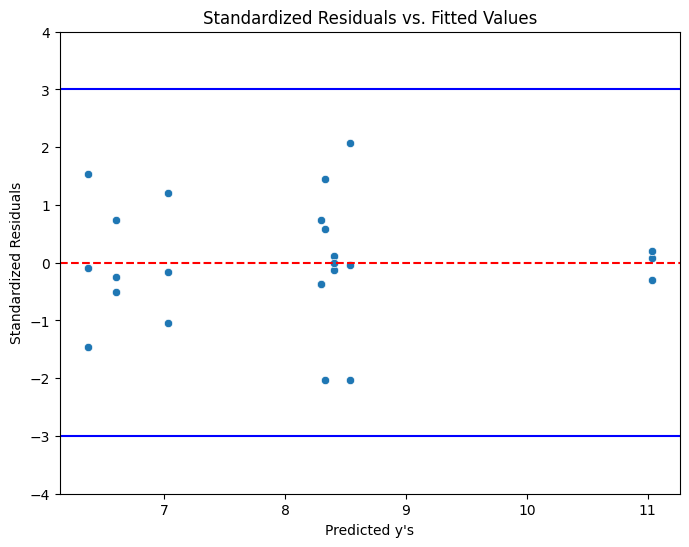

F-statistic: 2.278431684215503
F p-value: 0.0818079385294926
Fail to reject the null hypothesis - Variances are equal.


In [ ]:
## Test of Homogeneity of Variance ##
## Scatterplot of Standardized Residuals vs. Fitted Values ##
## Get Standardized Residuals ##
standardized_residuals = model.get_influence().resid_studentized_internal

## Get Fitted Values ##
fitted_values = model.fittedvalues

## Scatterplot ##
## Create the plot ##

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=standardized_residuals)
plt.axhline(y=0, linestyle='dashed', color='red')
plt.axhline(y=3, color='blue')
plt.axhline(y=-3, color='blue')
plt.xlabel("Predicted y's")
plt.ylabel("Standardized Residuals")
plt.title("Standardized Residuals vs. Fitted Values")
plt.style.use('classic')
plt.show()
## B-P Test ##
## Run B-P Test ##

bp_test = het_breuschpagan(residuals, model.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")
if f_p_value < 0.05:
    print("Reject the null hypothesis - Variances are not equal.")
else:
    print("Fail to reject the null hypothesis - Variances are equal.")

* For constant variance, none of our points are greater than +3 or less than -3, and the points appear randomly scattered around the horizontal line at 0. The B-P test p-value is greater than 0.05, supporting the assumption of the constant variance assumption.

9.  Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects? Our two-way interactions? Our three-way interaction?


In [ ]:
## Print ANOVA Table Results ##
anova_table = sm.stats.anova_lm(model, typ=3)

## Add Significance Column ##

anova_table["Significance"] = np.where(anova_table["PR(>F)"] < 0.05, "Significant", "Not Significant")

## Print Table Minus Intercept and Residual Rows ##

print(anova_table.drop(index=["Intercept", "Residual"]))


                                                    sum_sq   df             F  \
sole_material                                 5.606667e+00  1.0  5.812527e+00   
insole_thickness                              6.666667e-01  1.0  6.911447e-01   
breathability                                 8.166667e-02  1.0  8.466523e-02   
sole_material:insole_thickness                3.008333e-01  1.0  3.118790e-01   
sole_material:breathability                   9.466331e-30  1.0  9.813907e-30   
insole_thickness:breathability                9.633333e-01  1.0  9.987041e-01   
sole_material:insole_thickness:breathability  6.666667e-01  1.0  6.911447e-01   

                                                PR(>F)     Significance  
sole_material                                 0.028297      Significant  
insole_thickness                              0.418010  Not Significant  
breathability                                 0.774810  Not Significant  
sole_material:insole_thickness                0.584261 

* The main effect of sole material was statistically significant (F= 5.81, p= 0.02). The three-way interaction term (Sole material × Insole thickness × Breathability) was not statistically significant (F=0.69, p= 0.42 ).

* The two-way interaction terms (Sole Material × Insole thickness, Sole Material × Breathability, Insole thickness × Breathability) were also not statistically significant (all p > 0.05 ).

10. Calculate and interpret the partial $\eta^2$ values for each of the main effects and interactions. Which effects and/or interactions are most important? Why?


In [ ]:
!pip install pingouin
## Load pingouin ##
import pingouin as pg

## Fit ANOVA with pingouin ##

mod_p = pg.anova(dv='comfort',between=["sole_material","insole_thickness","breathability"],
                 data=shoe_data,effsize="np2").round(4)

print(mod_p[["Source","np2"]])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.1 MB/s eta 0:00:00
                                             Source     np2
0                                     sole_material  0.5965
1                                  insole_thickness  0.3779
2                                     breathability  0.3330
3                  sole_material * insole_thickness  0.0001
4                     sole_material * breathability  0.0414
5                  insole_thickness * breathability  0.2395
6  sole_material * insole_thickness * breathability  0.0414
7                                          Residual     NaN


* The main effects (Sole material, Insole thickness, and Breathability) all demonstrate large effect sizes, with np2 being greater than 0.14.

* The two-way interaction between insole thickness and breathability also shows a large effect size, with a np2 value of 0.2395, but it is not as large as the main effects.

* The remaining two-way interactions have  small effect sizes. The three-way interaction has a small effect size, even though it is close to medium, with a value of 0.04.

11. Summarize your conclusions. Which combination of factors would you recommend to the shoe manufacturer? Why?

 * The only factor in this experiment that was statisically signicant was sole material. I would suggest a gel 6mm woven shoe due to it yielding the highest mean comfort rating.



## PART 2 INSTRUCTIONS:
The same company is interested in developing a new GPS-enabled fitness band for runners. They want to maximize user satisfaction and have identified three key factors:

| Run | GPS Accuracy (A) | Battery Life (B) | Display (C) |
|-----|------------------|------------------|-------------|
| 1   | \- (Standard)    | \- (6 hours)     | \- (Small)  |
| 2   | \+ (High)        | \- (6 hours)     | \+ (Large)  |
| 3   | \- (Standard)    | \+ (12 hours)    | \+ (Large)  |
| 4   | \+ (High)        | \+ (12 hours)    | \- (Small)  |

Due to time and resource limitations, the company would rather conduct a $2^{3-1}$ fractional factorial experiment. For each of the above runs, the company will recruit 3 NCAA division one cross-country athletes to test a randomly assigned fitness band. Each athlete will use the band for one month during their competition season. At the end of the month, the athletes will be asked to rate their level of satisfaction on a scale of 1-10 (1 = very dissatisfied, 10 = very satisfied). The results of this experiment are contained in the `Fitness Band Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.
 * The objective of the experiment is to determine the factors of a GPS - enabled watch that users are most satisfied with using.

2.  Specify the outcome variable and how it is measured.
 * Outcome variable: Satisfication (continuous) based on each runner's rating from personal experience.

3.  Specify the independent variables. What lurking variables may be present?
 * Independent variables: Display, Battery life, and GPS accuracy
 * Lurking variables: Personal preference and skew the runner's satisfcation rating. For example, if a runner wears glasses or not, they may need bigger display.

4.  Explain the difference between a full $2^k$ factorial design and a $2^{3-1}$ fractional factorial design. Briefly comment on why the latter may be preferred in this case.
 * Fractional factorial design would test each combination of the factors with each level. Using $2^{3-1}$ fractional factorial design we do less runs trying to get the same information. In this case, $2^{3-1}$ fractional factorial design works because we are low on time and resources.

5.  State the sets of null and alternative hypotheses for this experiment.
- For main effects:

$$ H_{01}: \alpha_{\text{Standard}} = \alpha_{\text{High}} = 0 $$
$$ H_{11}: \text{At least one } \alpha_i \neq 0 $$

$$ H_{02}: \beta_{\text{6 hours}} = \beta_{\text{12 hours}} = 0 $$
$$ H_{12}: \text{At least one } \beta_j \neq 0 $$

$$ H_{03}: \gamma_{\text{Small}} = \gamma_{\text{Large}} = 0 $$
$$ H_{13}: \text{At least one } \gamma_k \neq 0 $$

- For two-way interactions:

$$ H_{04}: (\alpha\beta)_{ij} = 0 \text{ for all } i,j $$
$$ H_{14}: \text{At least one } (\alpha\beta)_{ij} \neq 0 $$

$$ H_{05}: (\alpha\gamma)_{ik} = 0 \text{ for all } i,k $$
$$ H_{15}: \text{At least one } (\alpha\gamma)_{ik} \neq 0 $$

$$ H_{06}: (\beta\gamma)_{jk} = 0 \text{ for all } j,k $$
$$ H_{16}: \text{At least one } (\beta\gamma)_{jk} \neq 0 $$

- For three-way interaction:

$$ H_{07}: (\alpha\beta\gamma)_{ijk} = 0 \text{ for all } i,j,k $$
$$ H_{17}: \text{At least one } (\alpha\beta\gamma)_{ijk} \neq 0 $$

6.  Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?
 *

7.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?


In [ ]:
## Import relevant libraries ##
import pandas as pd
import numpy as np

## Read in the Data ##

fitband_data = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW3/Fitness Band Experiment.xlsx")

## Evaluate the Data ##

print(fitband_data.info())
print(fitband_data.head())

## Add Effect Column to fitness band dataframe ##

fitband_data['Effect'] = np.repeat(["c","b","a","abc"],repeats=3)

print(fitband_data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Run_ID        12 non-null     int64  
 1   Replicate     12 non-null     int64  
 2   GPS_Accuracy  12 non-null     object 
 3   Battery_Life  12 non-null     object 
 4   Display       12 non-null     object 
 5   Satisfaction  12 non-null     float64
dtypes: float64(1), int64(2), object(3)
memory usage: 708.0+ bytes
None
   Run_ID  Replicate GPS_Accuracy Battery_Life Display  Satisfaction
0       1          1     Standard      6 Hours   Large          6.01
1       1          2     Standard      6 Hours   Large          5.91
2       1          3     Standard      6 Hours   Large          5.31
3       2          1         High      6 Hours   Small          4.70
4       2          2         High      6 Hours   Small          5.15
   Run_ID  Replicate GPS_Accuracy Battery_Life Display  Satisfaction

  GPS_Accuracy      mean       std
0         High  7.140000  2.346691
1     Standard  4.606667  1.284098
  Battery_Life      mean       std
0     12 Hours  6.368333  3.189303
1      6 Hours  5.378333  0.496806
  Display      mean       std
0   Large  7.505000  1.957445
1   Small  4.241667  0.886192


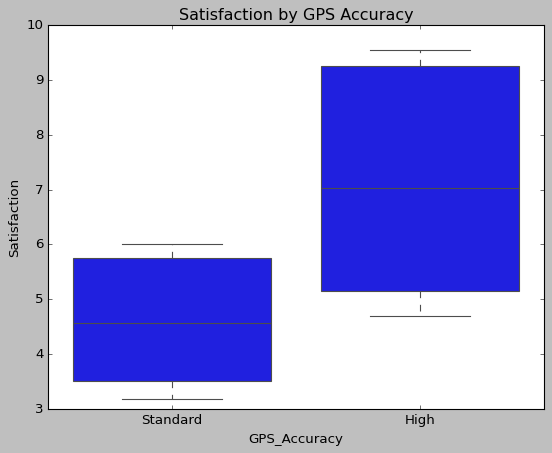

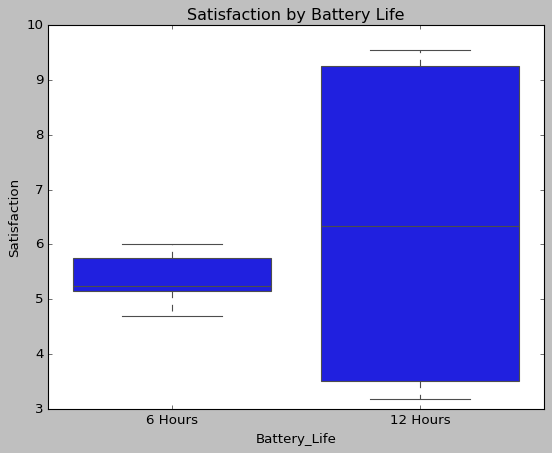

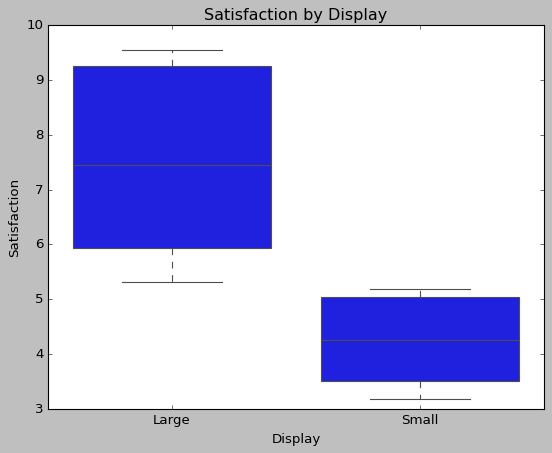

In [ ]:
## Calculate Summary Statistics for the Main Effects ##

import seaborn as sns
import matplotlib.pyplot as plt

## GPS Effect ##

gps_effect = fitband_data.groupby('GPS_Accuracy')['Satisfaction'].agg(['mean','std']).reset_index()

print(gps_effect)

## Battery Effect ##

battery_effect = fitband_data.groupby('Battery_Life')['Satisfaction'].agg(['mean','std']).reset_index()

print(battery_effect)

## Display Effect ##

display_effect = fitband_data.groupby('Display')['Satisfaction'].agg(['mean','std']).reset_index()

print(display_effect)

## Plot Boxplots for Each Factor using seaborn ##

## GPS Boxplot ##

sns.boxplot(x='GPS_Accuracy', y='Satisfaction', data=fitband_data)
plt.title('Satisfaction by GPS Accuracy')
plt.show()
## Battery Boxplot ##

sns.boxplot(x='Battery_Life', y='Satisfaction', data=fitband_data)
plt.title('Satisfaction by Battery Life')
plt.show()

## Display Boxplot ##
sns.boxplot(x='Display', y='Satisfaction', data=fitband_data)
plt.title('Satisfaction by Display')
plt.show()

* The boxplots for GPS accuracy and display demonstrate a difference in means between the two different levels of the factor. The summary statistics also support the gap in means when comparing the factor levels. Both the summary statistics and the box plots support the alternative hypothesis.
8.  Fit the appropriate ANOVA model to the data. Assess the normality assumption using both a testing method and a visual method. Do we have evidence to support the assumption of normality? Why or why not?


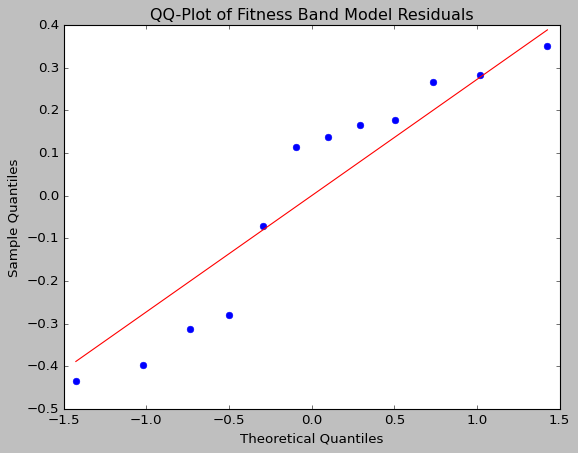

Shapiro-Wilk Test Results:
Statistic: 0.8812973148236574
p-value: 0.09106712364387089
Fail to reject the null hypothesis - Residuals are normally distributed.


In [ ]:
## Question 8 Code ##

import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy import stats
import matplotlib.pyplot as plt

## Fit ANOVA Model (Main Effects for fractional factorial) ##

# For a 2^(3-1) design with I=ABC, main effects are aliased with 2-way interactions.
# We typically model the main effects to estimate their generalized effects.
model_fitband = ols('Satisfaction ~ GPS_Accuracy + Battery_Life + Display', data=fitband_data).fit()

## Parse out model residuals ##
residuals_fitband = model_fitband.resid

## Test of Normality ##

## QQ-Plot ##
sm.qqplot(residuals_fitband, line='s')
plt.title("QQ-Plot of Fitness Band Model Residuals")
plt.show()

## Shapiro-Wilk Test ##
shapiro_test_fitband = stats.shapiro(residuals_fitband)

print("Shapiro-Wilk Test Results:")
print(f"Statistic: {shapiro_test_fitband.statistic}")
print(f"p-value: {shapiro_test_fitband.pvalue}")
if shapiro_test_fitband.pvalue < 0.05:
    print("Reject the null hypothesis - Residuals are not normally distributed.")
else:
    print("Fail to reject the null hypothesis - Residuals are normally distributed.")

* The Q-Q plot shows that the residuals are approximately normally distributed, with some deviation in the lower tail and middle. The S-W test statistic's p-value is greater than 0.05.

9.  Assess the constant variance assumption using both a testing method and a visual method. Do we have evidence to support the assumption of constant variance? Why or why not?


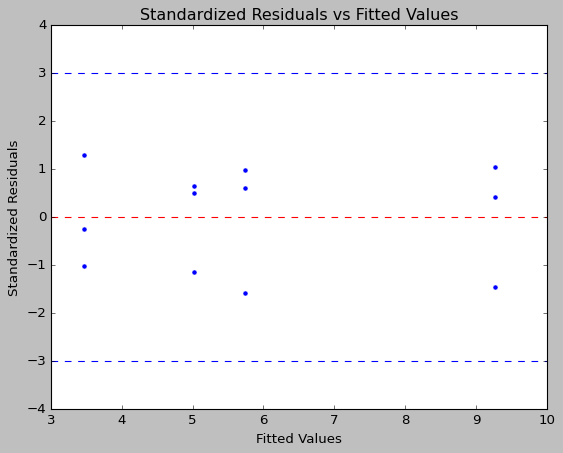

F-statistic: 0.2732704988386917
F p-value: 0.8431259020641402
Fail to reject the null hypothesis: No heteroscedasticity detected. Constant variance assumption holds.


In [ ]:
## Generate Scatterplot of Standardized Residuals vs Fitted Values ##

fitband_standard_res = model_fitband.get_influence().resid_studentized_internal
fitband_fitted_vals = model_fitband.fittedvalues # Corrected the typo here

sns.scatterplot(x=fitband_fitted_vals,y=fitband_standard_res)
plt.axhline(y=0, color='r', linestyle='--')
plt.axhline(y=3, color='b', linestyle='--')
plt.axhline(y=-3, color='b', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Standardized Residuals')
plt.title('Standardized Residuals vs Fitted Values')
plt.show()

## Perform Breusch-Pagan Test for Homoscedasticity ##

fitband_bp_test = het_breuschpagan(residuals_fitband, model_fitband.model.exog)

## Extract F-statistic ##

fitband_f_statistic = fitband_bp_test[2]

## Extract its P-Value ##

fitband_f_p_value = fitband_bp_test[3]

print(f"F-statistic: {fitband_f_statistic}")
print(f"F p-value: {fitband_f_p_value}")
if fitband_f_p_value < 0.05:
    print("Reject the null hypothesis: Heteroscedasticity detected. Constant variance assumption violated.")
else:
    print("Fail to reject the null hypothesis: No heteroscedasticity detected. Constant variance assumption holds.")

* The residuals vs. fitted values plot shows there are no points above +3 or below -3. The BP p-value is 0.84, which is greater than 0.05,indicating that there is no evidence to suggest that the constant variance assumption has been violated.
10. Report the F-statistics and their associated p-values from the factorial ANOVA model. What conclusions can we draw about our main effects?

In [ ]:
##ANOVA table ##
fit_anova_table = sm.stats.anova_lm(model_fitband, typ=1)

## Add Significance Column ##
fit_anova_table["Significance"] = np.where(fit_anova_table["PR(>F)"] < 0.05,
"Significant", "Not Significant")

## Print Table Minus Intercept and Residual Rows ##

print (fit_anova_table.drop(index=["Residual"]))

               df     sum_sq    mean_sq           F        PR(>F) Significance
GPS_Accuracy  1.0  19.253333  19.253333  172.869435  1.065588e-06  Significant
Battery_Life  1.0   2.940300   2.940300   26.400000  8.872097e-04  Significant
Display       1.0  31.948033  31.948033  286.851029  1.498222e-07  Significant


* GPS accuracy (F= 172.87, p < 0.05) is significant. Battery life (F= 26.4, p < 0.05) is significant. Display (F=286.85, p< 0.05) is significant. All of the main effects are significant due to the p-value being under the 0.05 threshold.

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [ ]:
## Group the Data by the Effect column and pivot from long to wide ##

df = (fitband_data.groupby("Effect", as_index=False)["Satisfaction"].mean())

## Now we want to pivot the DataFrame from long to wide format
## so that each effect is a separate column ##

df = df.pivot_table(index=None, columns='Effect', values='Satisfaction').reset_index(drop=True)

## Extract factor columns for easier use ##

a   = df['a']
b   = df['b']
c   = df['c']
abc = df['abc']

## Compute factor estimates ##

df2 = pd.DataFrame({
    "A": 0.5 * (a - b - c + abc),
    "B": 0.5 * (-a + b - c + abc),
    "C": 0.5 * (-a - b + c + abc)
})

print(df)
print(df2)

Effect     a       abc         b         c
0       3.47  9.266667  5.013333  5.743333
      A         B         C
0  0.99  2.533333  3.263333


* The effects that seem more important are

12. Calculate and interpret the partial $\eta^2$ values for each of the main effects. Which effects are most important? Why?

In [ ]:
## Load pingouin ##
import pingouin as pg

## Fit ANOVA with pingouin for the fitband data ##
mod_p_fitband = pg.anova(dv='Satisfaction', between=['GPS_Accuracy', 'Battery_Life', 'Display'],
                      data=fitband_data, effsize='np2').round(4)

print(mod_p_fitband[["Source", "np2"]])

                                  Source     np2
0                           GPS_Accuracy  0.9558
1                           Battery_Life  0.7674
2                                Display  0.9729
3            GPS_Accuracy * Battery_Life  0.9729
4                 GPS_Accuracy * Display  0.7674
5                 Battery_Life * Display  0.9558
6  GPS_Accuracy * Battery_Life * Display  0.9979
7                               Residual     NaN


* All main factors (GPS Accuracy, Battery Life, and Display) are  important (np2 values being large since greater than 0.7) and their interactions play a significant role in determining user satisfaction.

13. Summarize your conclusions. Which combination of factors would you recommend to the fitness band manufacturer? Why?